# Customer Churn Prediction at Telco Industry - PT Telkom Indonesia (Indihome)
### Created By : Nurul Balqis Apriany 

## Business Problem Understanding 

**Context**  

PT Telkom Indonesia is one of the largest telecommunication companies in Indonesia that provides internet and subscription services to customers. One of the major challenges faced by the company is customer churn, which occurs when customers stop using the company’s services.

Customer churn can negatively impact company revenue and increase the cost of acquiring new customers. Therefore, the company wants to identify customers who are likely to churn so preventive actions can be taken earlier.

The available data contains customer demographic information, subscription details, service usage, and billing information which can be used to analyze customer behavior related to churn.

Target:

* 0 : Customer does not churn
* 1 : Customer churns


**Problem Statement**

The company faces difficulties in identifying customers who are likely to stop using the service. Without a prediction system, the company may lose many customers without taking preventive action beforehand.

In addition, customer retention strategies such as discounts, promotions, and customer support improvements require additional cost and resources. Therefore, the company needs a way to focus retention efforts on customers who have a high probability of churning.

**Analytic Approach**

The approach used in this project is supervised learning with a classification method.

First, exploratory data analysis will be conducted to identify patterns and relationships between customer characteristics and churn behavior.

Then, several classification algorithms will be used to build predictive models, such as:

* Logistic Regression
* Decision Tree
* XGBoost
* Random Forest	

The performance of each model will then be compared to determine the best model for predicting customer churn.

**Metric Evaluation**

In this churn prediction case:

Type 1 Error : False Positive

The model predicts that a customer will churn, but actually the customer will stay.

Consequence:

* unnecessary retention cost,
* wasted promotions or discounts,
* inefficient allocation of company resources.


Type 2 Error : False Negative

The model predicts that a customer will stay, but actually the customer churns.

Consequence:

* loss of customers,
* loss of company revenue,
* missed opportunity to retain customers.


Based on these consequences, the company wants to minimize customer loss while still maintaining efficient retention costs.

Therefore, the main evaluation metrics used are:

* Recall
* F1-Score
* ROC-AUC

Because in churn prediction, detecting as many potential churn customers as possible is very important for the business.

Best model is selected based on:

  * Highest Recall
  * Highest F1-Score
  * Highest ROC-AUC Score


## Data Understanding

The dataset represents customer profiles who have left the telco company. A churn in telco and other subscription-based services means a situation when the customer leaves the service provider. 

### Notes :
- The dataset is used to predict customer churn in a telecommunication company.
- The dataset consists of categorical and numerical features.
- Most of the features are categorical (Nominal/Binary).
- Each row in the dataset represents one customer.
- The dataset has a binary classification target:
  - Yes = Customer churn
  - No = Customer does not churn
- The dataset is moderately imbalanced, where non-churn customers are more dominant than churn customers.


**Attribute Information**
| Attribute        | Data Type       | Description                                               |
|------------------|----------------|-----------------------------------------------------------|
| Dependents       | Text           | Whether the customer has dependents or not                |
| tenure           | Integer        | Number of months the customer has stayed with the company |
| OnlineSecurity   | Text           | Whether the customer has online security service          |
| OnlineBackup     | Text           | Whether the customer has online backup service            |
| InternetService  | Text           | Type of internet service subscribed by customer           |
| DeviceProtection | Text           | Whether the customer has device protection                |
| TechSupport      | Text           | Whether the customer has technical support service        |
| Contract         | Text           | Type of customer contract duration                        |
| PaperlessBilling | Text           | Whether customer uses paperless billing                   |
| MonthlyCharges   | Float          | Monthly amount charged to the customer                    |
| Churn            | Binary/Target  | Whether the customer churns or not                        |

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset 
df = pd.read_csv("data_telco_customer_churn.csv")
df.head()

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
0,Yes,9,No,No,DSL,Yes,Yes,Month-to-month,Yes,72.90,Yes
1,No,14,No,Yes,Fiber optic,Yes,No,Month-to-month,Yes,82.65,No
2,No,64,Yes,No,DSL,Yes,Yes,Two year,No,47.85,Yes
3,No,72,Yes,Yes,DSL,Yes,Yes,Two year,No,69.65,No
4,No,3,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,23.60,No


In [3]:
# Number of Rows and Columns
df.shape

(4930, 11)

In [4]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dependents        4930 non-null   object 
 1   tenure            4930 non-null   int64  
 2   OnlineSecurity    4930 non-null   object 
 3   OnlineBackup      4930 non-null   object 
 4   InternetService   4930 non-null   object 
 5   DeviceProtection  4930 non-null   object 
 6   TechSupport       4930 non-null   object 
 7   Contract          4930 non-null   object 
 8   PaperlessBilling  4930 non-null   object 
 9   MonthlyCharges    4930 non-null   float64
 10  Churn             4930 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 423.8+ KB


In [5]:
# Numeric Data Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,4930.0,32.401217,24.501193,0.0,9.00,29.00,55.00,72.00
MonthlyCharges,4930.0,64.883032,29.923960,18.8,37.05,70.35,89.85,118.65


In [6]:
# Check Missing Values
df.isna().sum()

Dependents          0
tenure              0
OnlineSecurity      0
OnlineBackup        0
InternetService     0
DeviceProtection    0
TechSupport         0
Contract            0
PaperlessBilling    0
MonthlyCharges      0
Churn               0
dtype: int64

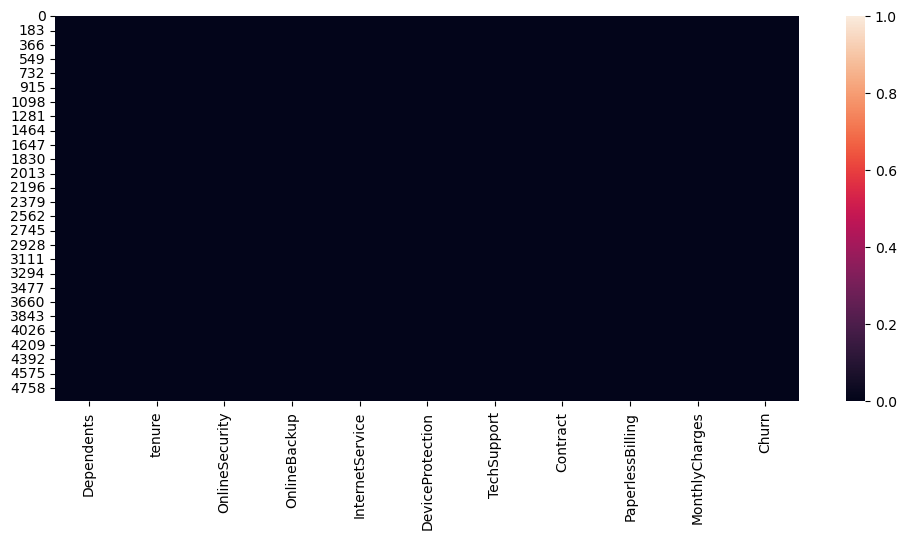

In [7]:
plt.figure(figsize = (12, 5))
sns.heatmap(data = df.isna(), vmin = 0, vmax = 1)
plt.show()

In [8]:
# Check duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 77


In [9]:
# Checking Inconsistent Values
for col in df.columns:
    print(col)
    print(df[col].unique())

Dependents
['Yes' 'No']
tenure
[ 9 14 64 72  3 40 17 11  8 47 18  5  1 48 13 58  7  4 70 34 31 37 15 71
 10 43 22 33 69 54 63 55 66 56 32 26 24  2 51 23 49 28 36 45 42  6 61 59
 67 65  0 16 52 41 25 62 20 50 30 60 19 35 57 27 44 53 12 46 39 29 38 68
 21]
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['No' 'Yes' 'No internet service']
InternetService
['DSL' 'Fiber optic' 'No']
DeviceProtection
['Yes' 'No internet service' 'No']
TechSupport
['Yes' 'No' 'No internet service']
Contract
['Month-to-month' 'Two year' 'One year']
PaperlessBilling
['Yes' 'No']
MonthlyCharges
[ 72.9   82.65  47.85 ...  58.45  23.65 108.5 ]
Churn
['Yes' 'No']


# Data Cleaning 


### Handling Duplicate Rows

The dataset contains 77 duplicate rows.

Duplicate rows are removed to avoid redundant data that may affect analysis results and machine learning model performance.

In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

In [11]:
# Recheck duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [12]:
df.shape

(4853, 11)

### Data Cleaning Conclusion

Based on the data understanding and data cleaning processes:
- the dataset contains 4,930 customer records and 11 features,
- no missing values were found,
- 77 duplicated rows were detected and removed,
- categorical values are consistent with no typographical errors,
- and all data types are appropriate.

The dataset consists of both numerical and categorical features, with the majority of columns being categorical variables. In addition, the target variable (`Churn`) shows a moderately imbalanced distribution, where non-churn customers are more dominant than churn customers.

Therefore, the dataset is considered clean, consistent, and ready for the Exploratory Data Analysis (EDA), preprocessing, and machine learning modeling stages.

# Exploratory Data Analysis (EDA) 

## 1. Target Distribution (Churn)

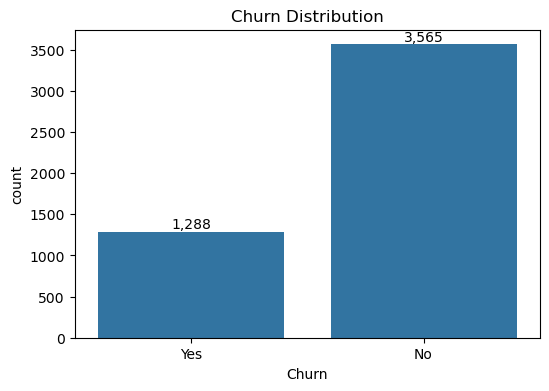

In [13]:
# Target Distribution (Churn)
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Churn', data=df)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Churn Distribution')

plt.show()

### Insight

Based on the target distribution:
- customers who did not churn dominate the dataset,
- where 3,565 customers stayed with the company,
- while 1,288 customers churned.

This indicates that the dataset is moderately imbalanced, with non-churn customers representing the majority class.

The imbalance is not considered extreme, but it should still be considered during the modeling and evaluation stages.

## 2. Univariate Analysis
### Categorical Features

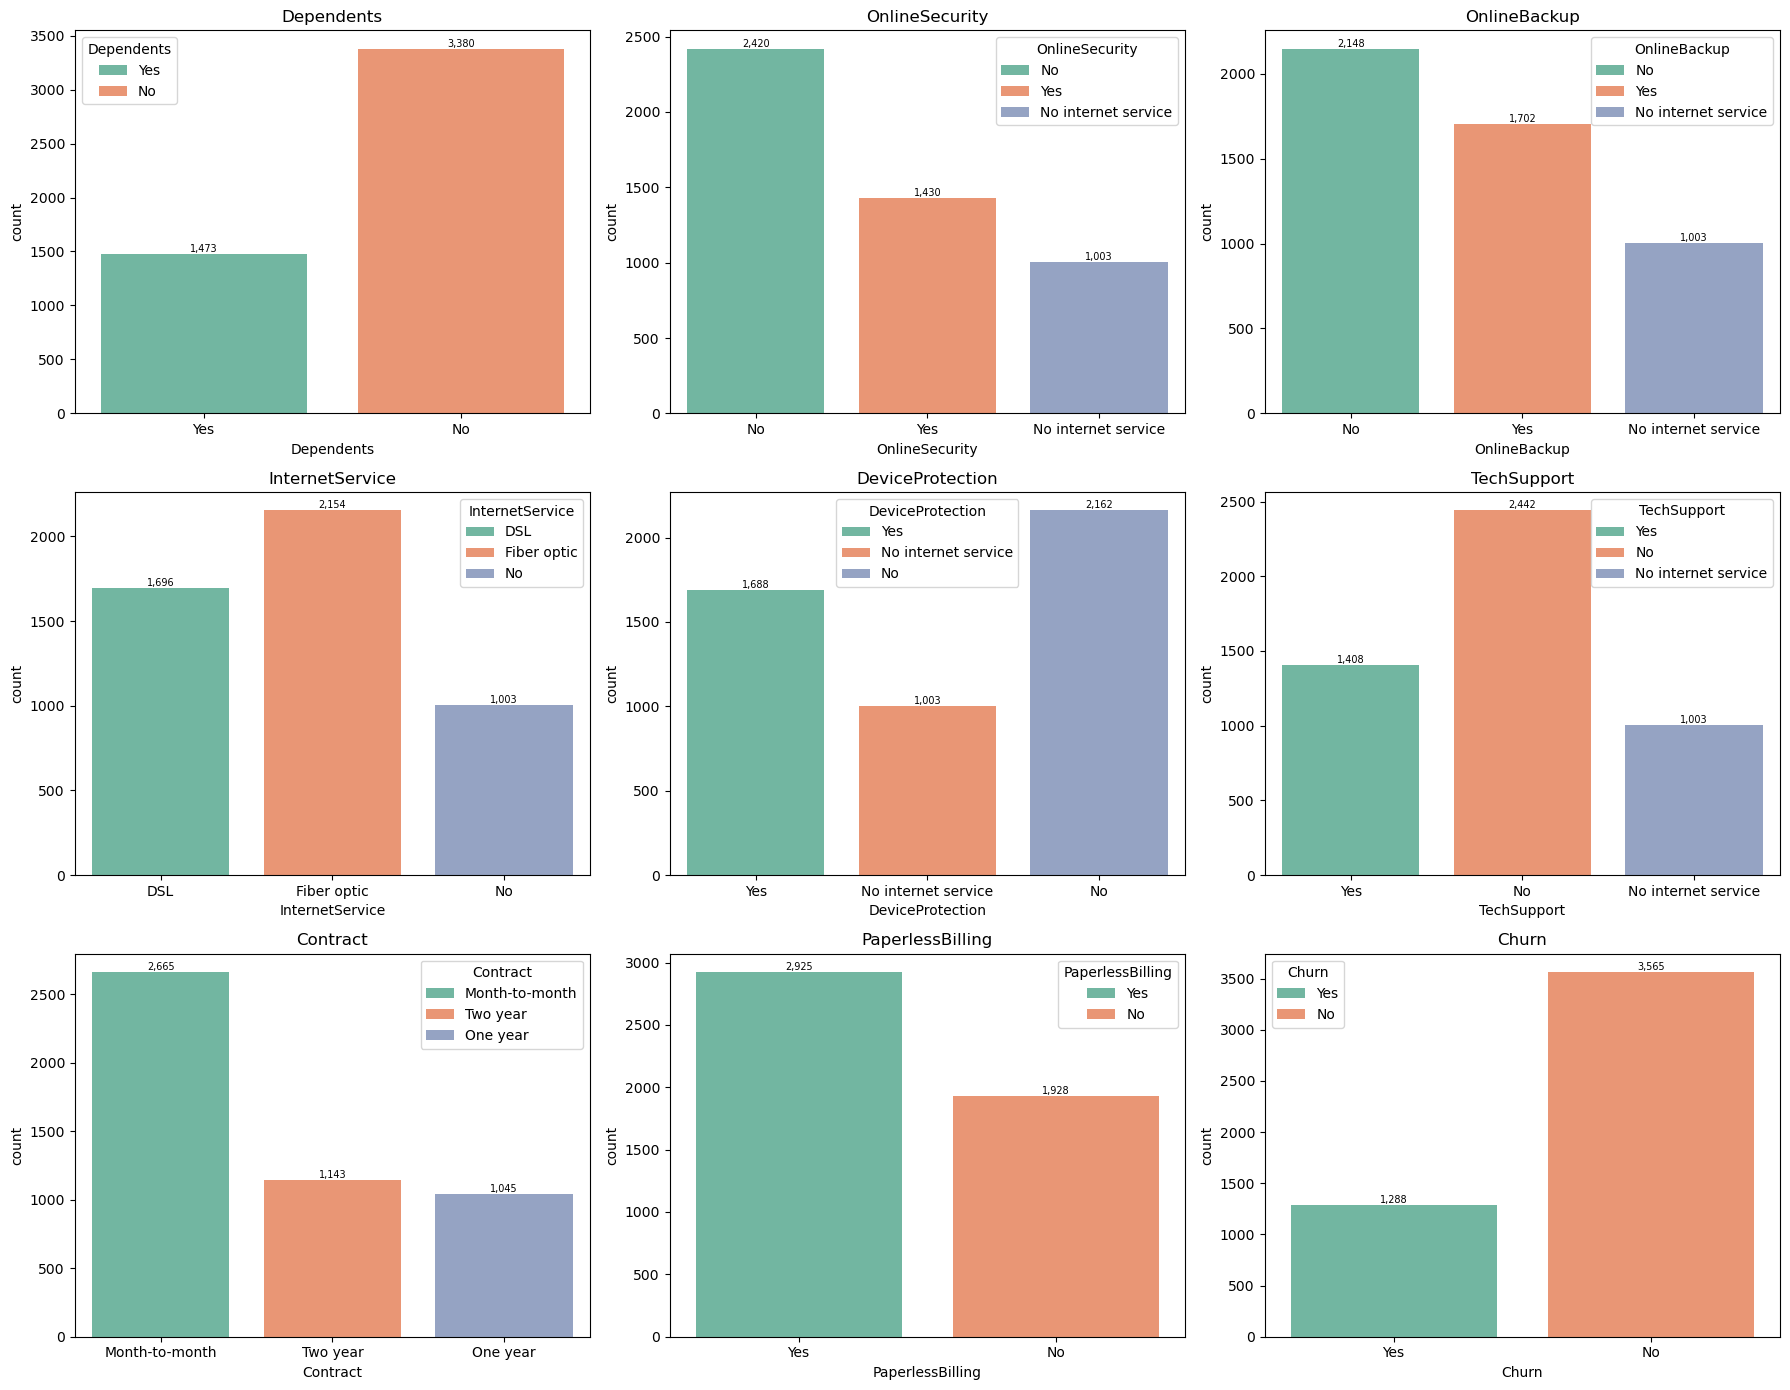

In [14]:
categorical_features = [
    'Dependents',
    'OnlineSecurity',
    'OnlineBackup',
    'InternetService',
    'DeviceProtection',
    'TechSupport',
    'Contract',
    'PaperlessBilling',
    'Churn'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    # ambil kategori unik
    categories = df[feature].unique()

    ax = sns.countplot(
        x=feature,
        data=df,
        hue=feature,
        palette='Set2',
        legend=False,
        ax=axes[i]
    )

    # annotation
    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height):,}',
            (p.get_x() + p.get_width()/2., height),
            ha='center',
            va='bottom',
            fontsize=7
        )

    axes[i].set_title(feature)

    # legend
    axes[i].legend(
        title=feature,
        labels=categories
    )

plt.tight_layout()
plt.show()

### Categorical Features Distribution Insights

- Most customers do not have dependents.
- Customers without online security services dominate the dataset.
- Customers without online backup services are more common.
- Fiber optic is the most widely used internet service.
- Most customers do not use device protection services.
- Customers without tech support services dominate the dataset.
- Month-to-month contracts are the most common contract type.
- Most customers prefer paperless billing.
- Non-churn customers dominate the dataset, indicating moderate class imbalance.

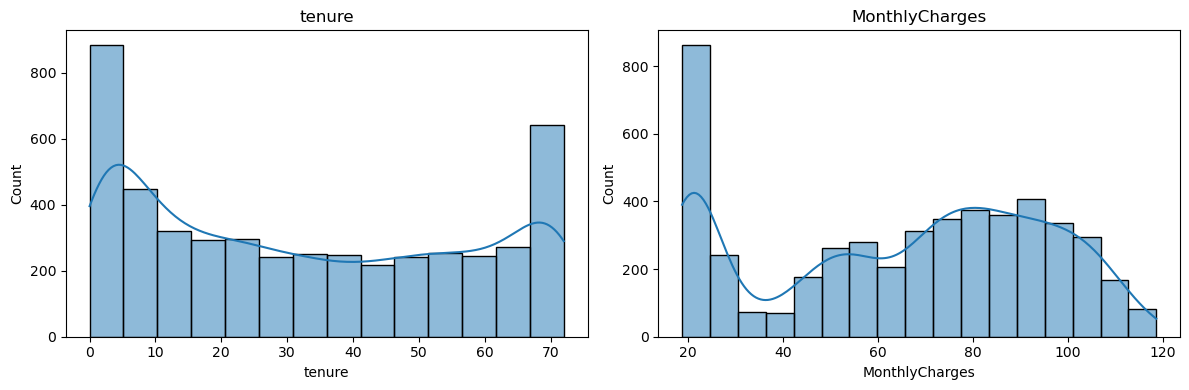

In [15]:
numerical_features = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, feature in enumerate(numerical_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

### Numerical Features Distribution Insights

- The `tenure` distribution indicates that the company has many newly subscribed customers, while a significant portion of customers also remain subscribed for a long period, showing a polarized customer retention pattern.
- The `MonthlyCharges` distribution is concentrated in the medium-to-high price range, indicating that most customers subscribe to higher-value service plans.
- Both numerical features exhibit non-normal distributions, suggesting potential skewness in customer behavior patterns that may influence machine learning model performance and preprocessing decisions.

## 3. Bivariate Analysis
### Categorical Features vs Churn

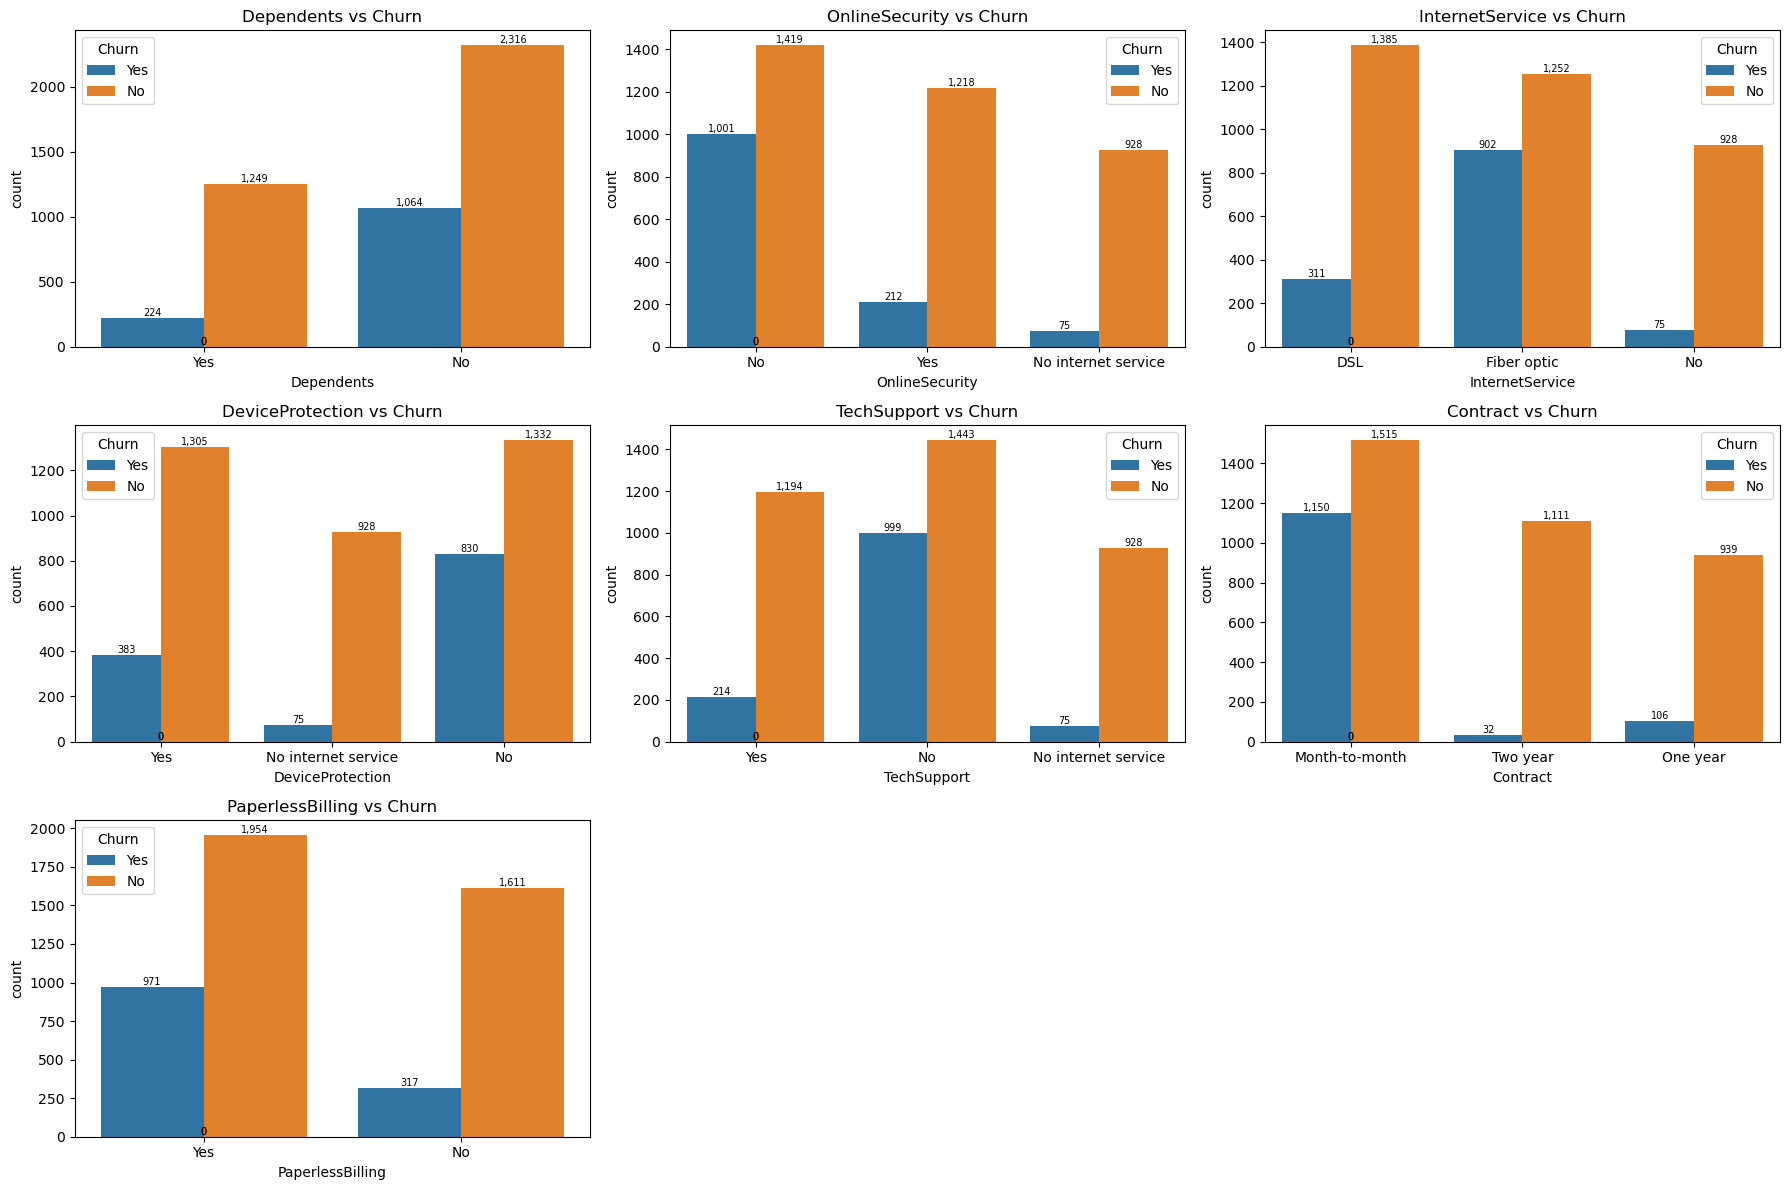

In [16]:
features = [
    'Dependents',
    'OnlineSecurity',
    'InternetService',
    'DeviceProtection',
    'TechSupport',
    'Contract',
    'PaperlessBilling'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):

    ax = sns.countplot(
        x=feature,
        hue='Churn',
        data=df,
        ax=axes[i]
    )

    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height()):,}',
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=7
        )

    axes[i].set_title(f'{feature} vs Churn')

# hapus subplot kosong
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Dependents vs Churn Insight

Customers without dependents have a much higher churn count:
- No dependents: 1,064 churn customers
- Have dependents: 224 churn customers

Meanwhile, customers with dependents are dominated by non-churn customers:
- Have dependents: 1,249 non-churn customers
- No dependents: 2,316 non-churn customers

This indicates that customers with dependents tend to be more loyal and less likely to churn compared to customers without dependents.


### Online Security vs Churn Insight

Customers without online security services have the highest churn count:
- No online security: 1,001 churn customers
- With online security: 212 churn customers
- No internet service: 75 churn customers

Meanwhile, customers with online security are dominated by non-churn customers:
- With online security: 1,218 non-churn customers

This indicates that online security services may help improve customer retention and reduce churn risk.

### Internet Service vs Churn Insight

Customers using Fiber optic internet service have the highest churn count:
- Fiber optic: 902 churn customers
- DSL: 311 churn customers
- No internet service: 75 churn customers

This indicates that Fiber optic customers are more likely to churn compared to other internet service categories.

### Device Protection vs Churn Insight

Customers without device protection have the highest churn count:
- No device protection: 830 churn customers
- With device protection: 383 churn customers
- No internet service: 75 churn customers

This indicates that customers without device protection services are more likely to churn.

### Tech Support vs Churn Insight

Customers without tech support have the highest churn count:
- No tech support: 999 churn customers
- With tech support: 214 churn customers
- No internet service: 75 churn customers

This indicates that customers without tech support services are more likely to churn.

### Contract vs Churn Insight

Customers with month-to-month contracts have the highest churn count:
- Month-to-month: 1,150 churn customers
- One year: 106 churn customers
- Two year: 32 churn customers

This indicates that short-term contracts are strongly associated with higher churn, while longer contracts show better customer retention.

### Paperless Billing vs Churn Insight

Customers using paperless billing have a higher churn count:
- Paperless billing (Yes): 971 churn customers
- Paperless billing (No): 317 churn customers

This indicates that customers using paperless billing tend to churn more compared to customers who do not use paperless billing.

### Numerical Features vs Target

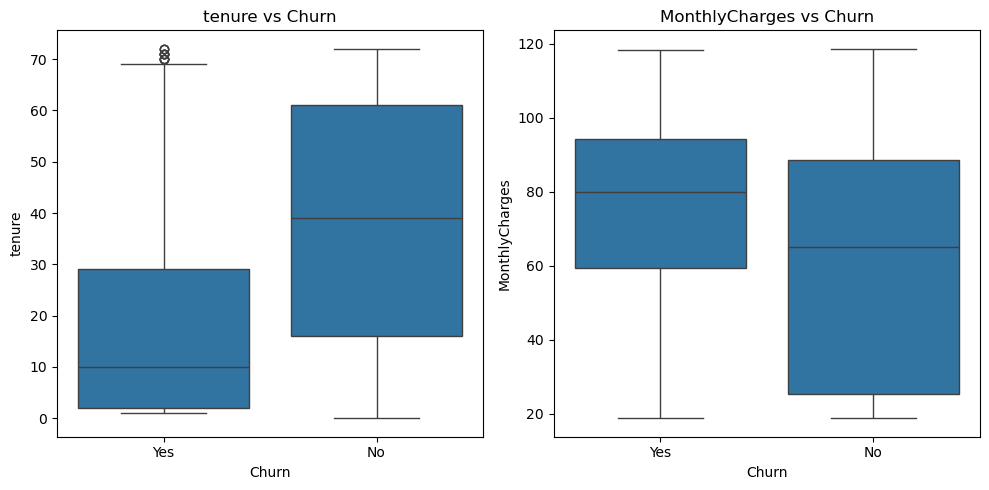

In [17]:
numerical_features = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(10,5))

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        x='Churn',
        y=feature,
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} vs Churn')

plt.tight_layout()
plt.show()

### Tenure vs Churn Insight

Based on the boxplot visualization, customers with lower tenure tend to churn more frequently compared to long-term customers.

The median tenure of churn customers is significantly lower, indicating that many customers leave the company during the early subscription period. Meanwhile, customers who remain with the company generally have much higher tenure values, showing stronger customer loyalty.

### Monthly Charges vs Churn Insight

Customers who churn tend to have higher monthly charges compared to those who stay. The median monthly charge for churned customers is around 80, while non-churn customers have a lower median around 65.

This indicates that higher service costs increase the likelihood of customer churn, while customers with lower monthly charges are more likely to stay with the company.

### Bivariate Analysis Insight

Based on bivariate analysis, **contract** type (especially **month-to-month contracts**) shows the **strongest** relationship with **customer churn**.

## 4. Multivariate Analysis
### Correlation Heatmap

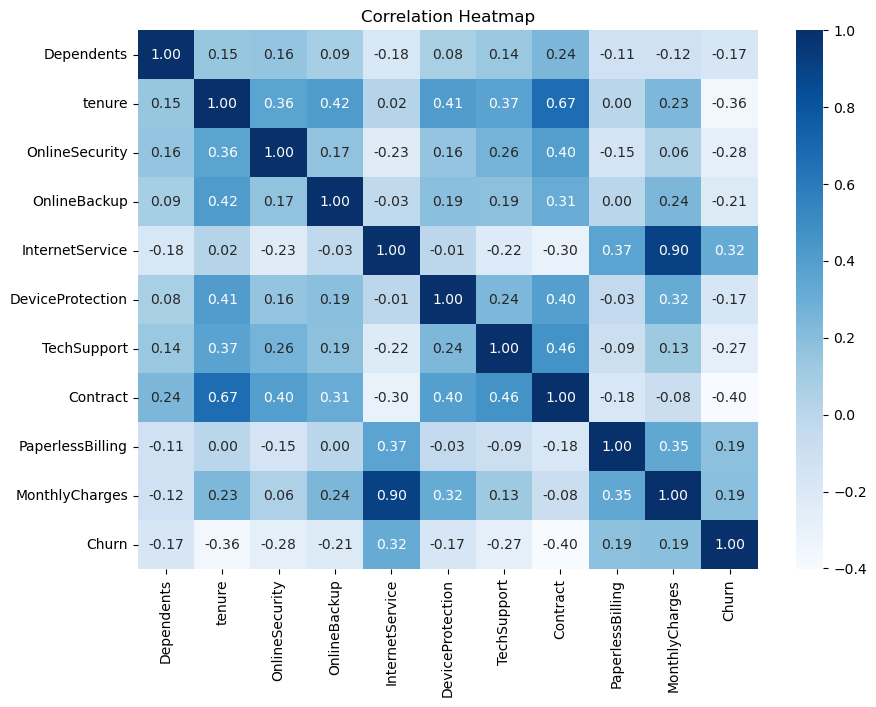

In [18]:
df_corr = df.copy()

# encode categorical
binary_map = {
    'Yes': 1,
    'No': 0
}

columns_to_encode = [
    'Dependents',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'PaperlessBilling',
    'Churn'
]

for col in columns_to_encode:
    df_corr[col] = df_corr[col].map(binary_map)

# contract encoding
df_corr['Contract'] = df_corr['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# internet service encoding
df_corr['InternetService'] = df_corr['InternetService'].map({
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
})

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Multivariate Analysis Insights

- `Contract` has the strongest negative correlation with `Churn` (-0.40), indicating that customers with longer-term contracts are less likely to churn.
- `tenure` also shows a moderate negative correlation with `Churn` (-0.36), suggesting that long-term customers tend to stay with the company.
- `InternetService` has a positive correlation with `Churn` (0.32), indicating that certain internet service types, especially fiber optic, are associated with higher churn rates.
- Additional services such as `OnlineSecurity` (-0.28) and `TechSupport` (-0.27) are negatively correlated with churn, suggesting these services may improve customer retention.
- `MonthlyCharges` shows a weak positive correlation with churn (0.19), meaning customers with higher monthly charges tend to churn slightly more often.
- Most feature correlations are relatively low to moderate, indicating limited multicollinearity and suggesting that the features provide different information for machine learning modeling.

## EDA Conclusion

Based on the univariate, bivariate, and multivariate analyses, several important churn patterns were identified.

Customer churn is strongly associated with **contract type, tenure, service support features, internet service type, and monthly charges**. Customers with **month-to-month contracts, shorter tenure, Fiber Optic internet services, higher monthly charges, and without additional services such as online security, device protection, and tech support** tend to have a significantly higher churn risk.

The analysis also shows that **long-term customers are generally more loyal**, as indicated by the negative correlation between tenure and churn. In addition, **longer contract durations are associated with lower churn rates**, making **contract type one of the strongest predictors of customer retention**.

From the service perspective, customers paying **higher service costs without additional support and protection services** are more likely to leave the company. This suggests that **value-added services may improve customer satisfaction and retention**.

Furthermore, the dataset shows **moderate class imbalance**, where non-churn customers dominate the target variable. Although the imbalance is not extreme, it should still be considered during model training and evaluation.

Overall, the EDA results indicate that customer churn is influenced by a combination of **customer commitment, service value, pricing, and additional support services**. These findings provide strong insights for **feature selection and machine learning modeling** in predicting customer churn.

# Data Preprocessing
## 1. Encoding categorical features

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

In [20]:
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn']) # Yes jadi 1, No jadi 0
df.head()

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
0,Yes,9,No,No,DSL,Yes,Yes,Month-to-month,Yes,72.90,1
1,No,14,No,Yes,Fiber optic,Yes,No,Month-to-month,Yes,82.65,0
2,No,64,Yes,No,DSL,Yes,Yes,Two year,No,47.85,1
3,No,72,Yes,Yes,DSL,Yes,Yes,Two year,No,69.65,0
4,No,3,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,23.60,0


## 2. Feature and Target Separation

In [21]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print('Feature Shape :', X.shape)
print('Target Shape  :', y.shape)

Feature Shape : (4853, 10)
Target Shape  : (4853,)


## 3. Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)
print('y_train :', y_train.shape)
print('y_test  :', y_test.shape)

X_train : (3882, 10)
X_test  : (971, 10)
y_train : (3882,)
y_test  : (971,)


## 4. Setup Preprocessor

In [24]:
from sklearn.compose import ColumnTransformer

In [25]:
categorical_cols = ['Dependents', 'OnlineSecurity', 'OnlineBackup', 'InternetService', 
                    'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling']
numerical_cols = ['tenure', 'MonthlyCharges']

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

In [27]:
## 5. Siapkan perhitungan rasio untuk XGBoost
# Calculate ratio to balance XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Model Selection using Cross Validation

### Define Modeling

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [29]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=5), # max_depth=5 agar tidak overfit
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
}

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score

In [31]:
# Store model evaluation results
results = []

# Loop through each model
for name, model in models.items():

    # Create pipeline with preprocessing and classifier
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Perform 5-Fold Cross Validation using Recall as evaluation metric
    recall_cv = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='recall'
    )

    # Save model performance results
    results.append({
        'Model': name,
        'Mean Recall CV': recall_cv.mean(),
        'Std Recall': recall_cv.std()
    })

# Convert results into DataFrame and sort by highest Recall
results_df = pd.DataFrame(results).sort_values(
    by='Mean Recall CV',
    ascending=False
)

# Display model comparison results
display(results_df)

,Model,Mean Recall CV,Std Recall
0,Logistic Regression,0.795146,0.022852
1,Decision Tree,0.748544,0.043570
3,XGBoost,0.649515,0.033828
2,Random Forest,0.457282,0.034517


### Model Comparison Visualization

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_18812\3133013072.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


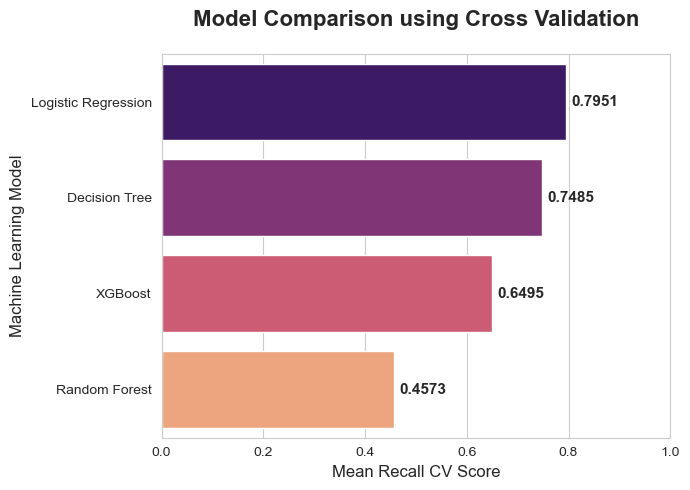

In [32]:
# Set the style for the plot
sns.set_style("whitegrid")

# Create the figure
plt.figure(figsize=(7, 5))

# Create bar plot for Mean Recall CV
ax = sns.barplot(
    x='Mean Recall CV',
    y='Model',
    data=results_df,
    palette='magma'
)

# Add titles and labels
plt.title('Model Comparison using Cross Validation', 
          fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Mean Recall CV Score', fontsize=12)
plt.ylabel('Machine Learning Model', fontsize=12)

# Set x-axis limit
plt.xlim(0, 1)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.4f}',
        (p.get_width() + 0.01,
         p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### **Model Selection Insight (Cross Validation – Class Weight)**

**Logistic Regression achieved the best overall performance** during the model selection process using 5-Fold Cross Validation.

The model obtained:
- **Highest Mean Recall CV (79.5%)**
- **Most stable performance** with relatively low standard deviation (**0.023**)

This indicates that **Logistic Regression consistently performs well in identifying churn customers** across different validation folds.

Although **Decision Tree** achieved moderate recall performance, its higher standard deviation suggests less stable predictions. Meanwhile, **Random Forest** and **XGBoost** produced significantly lower recall scores, making them less effective for churn detection.

Since the primary business objective is to **maximize churn detection**, **Logistic Regression was selected as the best baseline model** and will be used for **hyperparameter tuning**.

# Baseline Logistic Regression Modeling

In [33]:
# Baseline Logistic Regression Pipeline
baseline_lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])


In [34]:
# Train baseline model
baseline_lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
# Predict on test set
y_pred_baseline = baseline_lr_model.predict(X_test)

In [36]:
# Classification report for baseline model
print("Baseline Logistic Regression Performance\n")

print(classification_report(y_test, y_pred_baseline))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_pred_baseline):.4f}")

Baseline Logistic Regression Performance

              precision    recall  f1-score   support

           0       0.91      0.73      0.81       713
           1       0.52      0.81      0.63       258

    accuracy                           0.75       971
   macro avg       0.71      0.77      0.72       971
weighted avg       0.81      0.75      0.76       971

ROC-AUC Score : 0.7676


### **Baseline Logistic Regression Insight**

The baseline Logistic Regression model achieved an **accuracy of 75%**, indicating good overall classification performance.

For churn prediction (Class 1), the model produced:
- **Recall of 81%**
- **F1-Score of 63%**
- **Precision of 52%**
- **ROC-AUC Score of 76.8%**

The high recall score shows that the model is effective in identifying customers who are likely to churn, which is important for the business objective of minimizing customer loss.

In addition, the ROC-AUC score of **0.7676** indicates that the model has a good ability to distinguish between churn and non-churn customers.

However, the relatively lower precision indicates that some non-churn customers are still incorrectly predicted as churners. Despite this, the model provides a strong baseline performance and is suitable for further improvement through hyperparameter tuning.

# Hyperparameter Tuning

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
# 1. Reassemble the Pipeline specifically for Logistic Regression
pipeline_lr_tune = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

In [39]:
# 2. Set up the "Modification Menu" (Hyperparameter Grid)
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs', 'newton-cg']
}

In [40]:
# 3. Prepare the engine that will find the best combination (GridSearchCV)
grid_search = GridSearchCV(
    estimator=pipeline_lr_tune,
    param_grid=param_grid,
    cv=5,               
    scoring='recall',   # OUR MAIN BUSINESS FOCUS
    n_jobs=-1,          
    verbose=1           
)

In [41]:
# 4. Execute! Let it test all combinations automatically
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.001, 0.01, ...], 'classifier__solver': ['liblinear', 'lbfgs', ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [42]:
# 5. Retrieve the Best Model
best_lr_model = grid_search.best_estimator_

print("TUNING COMPLETED!")
print("Best Hyperparameter Settings:", grid_search.best_params_)

TUNING COMPLETED!
Best Hyperparameter Settings: {'classifier__C': 0.001, 'classifier__solver': 'liblinear'}


# Test the Best Model

In [43]:
# 6. Final Exam: Test the Best Model on the Unseen Test Data
y_pred_tuned = best_lr_model.predict(X_test)

In [44]:
# Print Final Evaluation using Classification Report
print("========== FINAL REPORT: BEST MODEL ==========")
print(classification_report(y_test, y_pred_tuned))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_pred_tuned):.4f}")
print("===============================================")

========== FINAL REPORT: BEST MODEL ==========
              precision    recall  f1-score   support

           0       0.91      0.72      0.81       713
           1       0.51      0.80      0.62       258

    accuracy                           0.74       971
   macro avg       0.71      0.76      0.71       971
weighted avg       0.80      0.74      0.76       971

ROC-AUC Score : 0.7623


### Model Interpretation (After Tuning)

The tuned Logistic Regression model shows **stable and reliable performance** for churn prediction.

- **Accuracy: 74%**
- **Recall: 80%** → strong at detecting churn customers  
- **Precision: 51%** → acceptable trade-off  
- **ROC-AUC: 0.762** → good separation ability  

The model is **well-generalized (no over/underfitting)** and optimized for **recall-focused churn detection**, making it **business-ready for retention strategy**.

# Baseline vs Tuned Comparison

In [45]:
# Create comparison DataFrame
comparison_tuning = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    
    'Before Tuning (Baseline)': [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_pred_baseline)
    ],
    
    'After Tuning (Best Model)': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_pred_tuned)
    ]
})

# Display comparison table
print("Final Comparison: Baseline vs Tuned Logistic Regression")
display(comparison_tuning)

Final Comparison: Baseline vs Tuned Logistic Regression


,Metric,Before Tuning (Baseline),After Tuning (Best Model)
0,Accuracy,0.747683,0.743563
1,Precision,0.516049,0.511111
2,Recall,0.810078,0.802326
3,F1-Score,0.630468,0.624434
4,ROC-AUC,0.767591,0.762313


### **Baseline vs Tuned Model Comparison Insight**

The comparison results show that the tuned Logistic Regression model produced performance that is very similar to the baseline model.

After hyperparameter tuning:
- **Recall slightly decreased** from **81.0%** to **80.2%**
- **Accuracy slightly decreased** from **74.8%** to **74.4%**
- **F1-Score slightly decreased** from **63.0%** to **62.4%**
- **ROC-AUC slightly decreased** from **76.8%** to **76.2%**

These results indicate that hyperparameter tuning did not significantly improve the model performance. The performance differences between the baseline and tuned model are relatively small.

This suggests that the baseline Logistic Regression model was already well-optimized and stable for the churn prediction task.

Since the primary business objective is to maximize churn detection, the baseline Logistic Regression model remains highly effective in identifying customers who are likely to churn, with consistently strong recall performance.

# Model Performance: Train VS Test

In [46]:
# ==========================================
# FINAL MODEL PERFORMANCE: TRAIN VS TEST
# ==========================================

# 1. Get predictions for both sets
y_pred_train = best_lr_model.predict(X_train)
y_pred_test = best_lr_model.predict(X_test)

# 2. Create a comparison dictionary
comparison_results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Train Score": [
        accuracy_score(y_train, y_pred_train),
        precision_score(y_train, y_pred_train),
        recall_score(y_train, y_pred_train),
        f1_score(y_train, y_pred_train),
        roc_auc_score(y_train, y_pred_train)
    ],
    "Test Score": [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test),
        recall_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test),
        roc_auc_score(y_test, y_pred_test)
    ]
}

# 3. Display as a clean DataFrame
comparison_df = pd.DataFrame(comparison_results)
print("Comparison of Training and Testing Performance:")
display(comparison_df)

Comparison of Training and Testing Performance:


,Metric,Train Score,Test Score
0,Accuracy,0.737506,0.743563
1,Precision,0.503360,0.511111
2,Recall,0.800000,0.802326
3,F1-Score,0.617923,0.624434
4,ROC-AUC,0.757468,0.762313


### **Training vs Testing Performance Insight**

The training and testing results show very similar performance across all evaluation metrics.

This indicates that the model generalizes well to unseen data and does not show significant signs of overfitting.

Overall, the Logistic Regression model demonstrates stable and reliable performance for churn prediction.

# Feature Importance

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_18812\4201900180.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='RdYlGn_r')


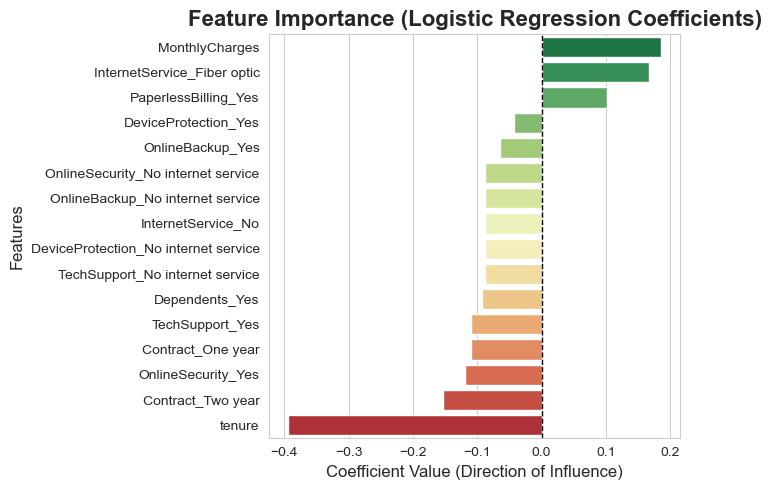

In [47]:
# 1. Extract feature names from the preprocessor
# Numerical column names
num_features = numerical_cols 

# Categorical column names after OneHotEncoder
cat_features = best_lr_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)

# Combine all feature names
all_features = np.concatenate([num_features, cat_features])

# 2. Extract coefficients from the Logistic Regression classifier
coefficients = best_lr_model.named_steps['classifier'].coef_[0]

# 3. Create a DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})

# Sort by coefficient value (from strongest positive to strongest negative)
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

# 4. Visualization
plt.figure(figsize=(7, 5))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='RdYlGn_r')

plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=16, fontweight='bold')
plt.xlabel('Coefficient Value (Direction of Influence)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Zero line for reference
plt.tight_layout()
plt.show()

### Interpretasi Feature Importance: (Logistic Regression)

The coefficient analysis reveals two clear patterns driving customer churn:

**Churn Drivers (Positive Impact):**
Customers with **Month-to-Month contracts**, **higher Monthly Charges**, and **Fiber Optic internet service** are more likely to churn. This reflects price sensitivity and low commitment levels as key risk factors.

**Retention Factors (Negative Impact):**
Longer **Tenure**, **One/Two-year contracts**, and add-on services such as **Online Security** and **Tech Support** significantly reduce churn probability. These features act as strong retention anchors by increasing switching costs and customer dependency.

### Key Insight
Churn is primarily driven by **low commitment contracts and high pricing pressure**, while retention is strengthened through **long-term contracts and value-added services**.

# Business Condition Before vs After Machine Learning

In [48]:
# 1. Prepare simulation data from the Test Set
sim_df = X_test.copy()
sim_df['Actual_Churn'] = y_test.values
sim_df['Predicted_Churn'] = best_lr_model.predict(X_test)

# 2. Business Parameters
promo_cost = 5  # Cost of the promotion per targeted customer
retention_success_rate = 0.50  # 50% of targeted churners are successfully retained

# --- SCENARIO 1: WITHOUT MODEL (Status Quo) ---
# We lose 100% of actual churners and their associated monthly revenue
total_actual_churners = sim_df[sim_df['Actual_Churn'] == 1]
loss_no_model = total_actual_churners['MonthlyCharges'].sum()

# --- SCENARIO 2: WITH MODEL (Targeted Retention) ---

# A. True Positives (Successfully Flagged):
# We give them a promo. 50% stay (revenue saved), 50% still leave (revenue lost).
tp_df = sim_df[(sim_df['Predicted_Churn'] == 1) & (sim_df['Actual_Churn'] == 1)]
tp_count = len(tp_df)
tp_promo_total_cost = tp_count * promo_cost
tp_revenue_still_lost = tp_df['MonthlyCharges'].sum() * (1 - retention_success_rate)

# B. False Positives (False Alarms):
# Loyal customers flagged as churners. We give them a promo unnecessarily.
fp_df = sim_df[(sim_df['Predicted_Churn'] == 1) & (sim_df['Actual_Churn'] == 0)]
fp_count = len(fp_df)
fp_promo_waste_cost = fp_count * promo_cost

# C. False Negatives (Missed Churners):
# They leave without us noticing. Total revenue loss.
fn_df = sim_df[(sim_df['Predicted_Churn'] == 0) & (sim_df['Actual_Churn'] == 1)]
fn_revenue_lost = fn_df['MonthlyCharges'].sum()

# Calculate Total Loss with Model implementation
total_loss_with_model = tp_promo_total_cost + tp_revenue_still_lost + fp_promo_waste_cost + fn_revenue_lost

# 3. Final Results Calculation
total_revenue_saved = loss_no_model - total_loss_with_model
efficiency_increase_pct = (total_revenue_saved / loss_no_model) * 100

print(f"--- BUSINESS SIMULATION (Sample: {len(X_test)} Test Customers) ---")
print(f"Revenue Loss WITHOUT Model : ${loss_no_model:,.2f}")
print(f"Revenue Loss WITH Model    : ${total_loss_with_model:,.2f}")
print("-" * 50)
print(f"TOTAL REVENUE SAVED        : ${total_revenue_saved:,.2f}")
print(f"RETENTION EFFICIENCY       : {efficiency_increase_pct:.2f}%")

--- BUSINESS SIMULATION (Sample: 971 Test Customers) ---
Revenue Loss WITHOUT Model : $19,280.55
Revenue Loss WITH Model    : $13,232.73
--------------------------------------------------
TOTAL REVENUE SAVED        : $6,047.82
RETENTION EFFICIENCY       : 31.37%


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_18812\4223163218.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=scenarios, y=losses, palette=['#e74c3c', '#2ecc71'])


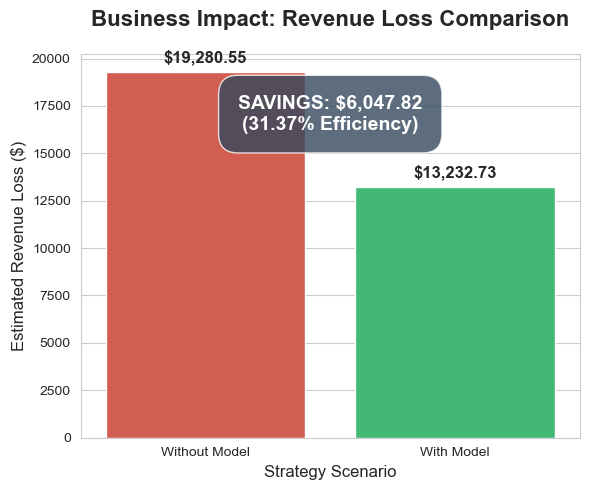

In [49]:
# 1. Prepare data for visualization
scenarios = ['Without Model', 'With Model']
losses = [loss_no_model, total_loss_with_model]

# 2. Create the plot
plt.figure(figsize=(6, 5))
sns.set_style("whitegrid")

# Bar plot
ax = sns.barplot(x=scenarios, y=losses, palette=['#e74c3c', '#2ecc71'])

# 3. Add titles and labels
plt.title('Business Impact: Revenue Loss Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Estimated Revenue Loss ($)', fontsize=12)
plt.xlabel('Strategy Scenario', fontsize=12)

# 4. Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

# 5. Add a highlighted "Savings" annotation
plt.text(0.5, (loss_no_model + total_loss_with_model)/2, 
         f'SAVINGS: ${total_revenue_saved:,.2f}\n({efficiency_increase_pct:.2f}% Efficiency)', 
         fontsize=14, color='white', fontweight='bold', ha='center',
         bbox=dict(facecolor='#34495e', alpha=0.8, boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()

In [50]:
from sklearn.metrics import confusion_matrix

In [51]:
# ===============================
# BUSINESS IMPACT SIMULATION
# ===============================

# Prediction result
y_pred_test = best_lr_model.predict(X_test)

# Prepare simulation data
sim_df = X_test.copy()
sim_df['Actual_Churn'] = y_test.values
sim_df['Predicted_Churn'] = y_pred_test

# Business assumptions
promo_cost = 5
retention_success_rate = 0.50

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Scenario 1: Without Model
# All actual churn customers are lost
loss_without_model = sim_df[sim_df['Actual_Churn'] == 1]['MonthlyCharges'].sum()

# Scenario 2: With Model
tp_df = sim_df[(sim_df['Actual_Churn'] == 1) & (sim_df['Predicted_Churn'] == 1)]
fp_df = sim_df[(sim_df['Actual_Churn'] == 0) & (sim_df['Predicted_Churn'] == 1)]
fn_df = sim_df[(sim_df['Actual_Churn'] == 1) & (sim_df['Predicted_Churn'] == 0)]

# Cost components
tp_promo_cost = len(tp_df) * promo_cost
fp_promo_cost = len(fp_df) * promo_cost
tp_remaining_loss = tp_df['MonthlyCharges'].sum() * (1 - retention_success_rate)
fn_loss = fn_df['MonthlyCharges'].sum()

loss_with_model = tp_promo_cost + fp_promo_cost + tp_remaining_loss + fn_loss

# Business impact
savings = loss_without_model - loss_with_model
efficiency_gain = (savings / loss_without_model) * 100

print("========== BUSINESS IMPACT SIMULATION ==========")
print(f"Test customers              : {len(X_test)}")
print(f"True Positive               : {tp}")
print(f"False Positive              : {fp}")
print(f"False Negative              : {fn}")
print(f"True Negative               : {tn}")
print("================================================")

========== BUSINESS IMPACT SIMULATION ==========
Test customers              : 971
True Positive               : 207
False Positive              : 198
False Negative              : 51
True Negative               : 515


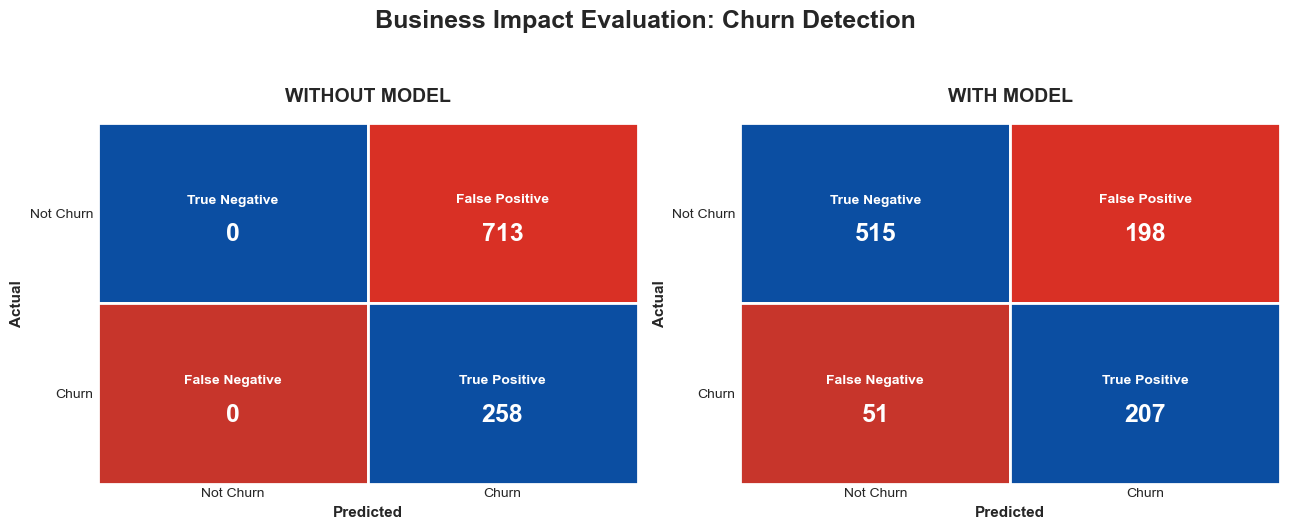

In [52]:
# ===============================
# CONFUSION MATRIX BUSINESS VISUALIZATION
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scenario 1: Without Model
# Tanpa model, semua customer churn tidak terdeteksi
without_model = np.array([
    [0, tn + fp],   # semua actual not churn dianggap tidak ada deteksi
    [0, tp + fn]    # semua actual churn tidak ditangani
])

# Scenario 2: With Model
with_model = np.array([
    [tn, fp],
    [fn, tp]
])

titles = ["WITHOUT MODEL", "WITH MODEL"]
matrices = [without_model, with_model]

labels = [
    ["True Negative", "False Positive"],
    ["False Negative", "True Positive"]
]

colors = [
    ["#0B4EA2", "#D93025"],
    ["#C7352B", "#0B4EA2"]
]

for ax, matrix, title in zip(axes, matrices, titles):
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)

    for i in range(2):
        for j in range(2):
            ax.add_patch(
                plt.Rectangle(
                    (j, i),
                    1,
                    1,
                    color=colors[i][j],
                    ec="white",
                    lw=2
                )
            )

            ax.text(
                j + 0.5,
                i + 0.43,
                labels[i][j],
                ha="center",
                va="center",
                color="white",
                fontsize=10,
                fontweight="bold"
            )

            ax.text(
                j + 0.5,
                i + 0.62,
                f"{matrix[i, j]}",
                ha="center",
                va="center",
                color="white",
                fontsize=18,
                fontweight="bold"
            )

    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)

    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Not Churn", "Churn"], fontsize=10)

    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Not Churn", "Churn"], fontsize=10)

    ax.set_xlabel("Predicted", fontsize=11, fontweight="bold")
    ax.set_ylabel("Actual", fontsize=11, fontweight="bold")

    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle(
    "Business Impact Evaluation: Churn Detection",
    fontsize=18,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()

### Simulation Insight

The churn prediction model delivers a clear and measurable business impact.

By using the model, the company reduces potential revenue loss from **$19,280.55 to $13,232.73**, resulting in a total saving of **$6,047.82** from only 971 customers.

This translates to a **Retention Efficiency of 31.37%**, meaning the model is able to successfully help prevent nearly one-third of potential revenue leakage.

The model is not only statistically effective but also **financially valuable**, as it significantly reduces churn-related revenue loss and provides a strong foundation for targeted retention strategies.

# Conclusion 

Based on the final tuned model, we can conclude that the Logistic Regression model is **stable, well-generalized, and business-ready** for churn prediction.

The model achieves:
- **Recall: 80%** → successfully captures most customers who will churn  
- **Precision: 51%** → acceptable level of targeting efficiency  
- **ROC-AUC: 0.762** → good separation between churn and non-churn customers  

Overall, the model is optimized for a **recall-driven business objective**, ensuring that most high-risk customers are successfully identified for retention actions.

## Business Recommendation

- Focus retention only on **high-risk customers (Month-to-month, high charges, Fiber optic)**  
- Push **contract upgrade (monthly → yearly)** to increase customer lock-in  
- Promote **add-on services (Security, Tech Support)** to improve retention  
- Review pricing strategy for high-cost customers to reduce churn  
- Continuously improve model with new behavioral data and error analysis (False Negatives)
---

## Model Limitations (The 20% Gap): 

Although the model performs well, there is still a **20% False Negative rate**, meaning some churn customers are not detected.

These cases usually happen because:
- Customer behavior is not fully captured in the dataset  
- External factors (competitor offers, personal decisions) are unknown to the model  
- There is a natural trade-off between **recall and precision**

In simple terms: the model is strong, but not perfect—this is expected in real-world prediction systems.

---

## Business Impact Insight

The model successfully reduces revenue loss:

- Revenue loss without model: **$19,280.55**
- Revenue loss with model: **$13,232.73**
- **Total savings: $6,047.82**
- **Retention efficiency: 31.37%**

This shows that the model can significantly reduce unnecessary outreach while still capturing most churn-prone customers.

---

## Recommendations for Improvement

To further improve model performance and business impact, the following steps can be considered:

### 1. Feature Enhancement
Add more behavioral and contextual features such as:
- Customer service interaction history  
- Complaint frequency or support tickets  
- Payment delays or billing issues  
- Usage behavior (data consumption, service activity)

---

### 2. Data Quality Improvement
Improve dataset completeness by:
- Reducing missing or inconsistent categorical inputs  
- Standardizing customer profile information  
- Ensuring richer historical tracking of customer behavior  

---

### 3. Model Improvement
Experiment with:
- Advanced models (XGBoost tuning, LightGBM, ensemble methods)  
- Alternative resampling techniques (SMOTE, SMOTENC)  
- Threshold tuning to optimize recall vs precision trade-off  

---

### 4. Error Analysis
Analyze **False Negatives (missed churners)** to:
- Understand what patterns the model fails to capture  
- Identify hidden churn drivers not represented in current features  
- Improve feature engineering strategy  

---

## Final Takeaway
The current model is **already effective for deployment**, but its performance can still be improved through better features, deeper error analysis, and model optimization. The system provides a strong foundation for a **data-driven customer retention strategy**.